## DATA PREPROCESSING AND DATA CLEANING

In [ ]:
!pip install torch torchvision timm matplotlib scikit-learn

In [ ]:
import zipfile

# Adjust name if your file name changes after re-upload
with zipfile.ZipFile("Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("Dataset")

print("✅ Extracted successfully!")

✅ Extracted successfully!


Using device: cuda
Epoch 1/16, Train Loss: 0.7808, Val Loss: 0.7348
Epoch 2/16, Train Loss: 0.7205, Val Loss: 0.7171
Epoch 3/16, Train Loss: 0.7078, Val Loss: 0.7582
Epoch 4/16, Train Loss: 0.6710, Val Loss: 0.6272
Epoch 5/16, Train Loss: 0.6013, Val Loss: 0.4708
Epoch 6/16, Train Loss: 0.5159, Val Loss: 0.4464
Epoch 7/16, Train Loss: 0.4121, Val Loss: 0.3460
Epoch 8/16, Train Loss: 0.3108, Val Loss: 0.2511
Epoch 9/16, Train Loss: 0.2218, Val Loss: 0.1483
Epoch 10/16, Train Loss: 0.1230, Val Loss: 0.0588
Epoch 11/16, Train Loss: 0.1297, Val Loss: 0.0942
Epoch 12/16, Train Loss: 0.1043, Val Loss: 0.0956
Epoch 13/16, Train Loss: 0.1064, Val Loss: 0.0956
Epoch 14/16, Train Loss: 0.0584, Val Loss: 0.0414
Epoch 15/16, Train Loss: 0.0740, Val Loss: 0.0174
Epoch 16/16, Train Loss: 0.0412, Val Loss: 0.0162

Classification Report:
              precision    recall  f1-score   support

        fake       1.00      1.00      1.00       570
        real       1.00      1.00      1.00       620

  

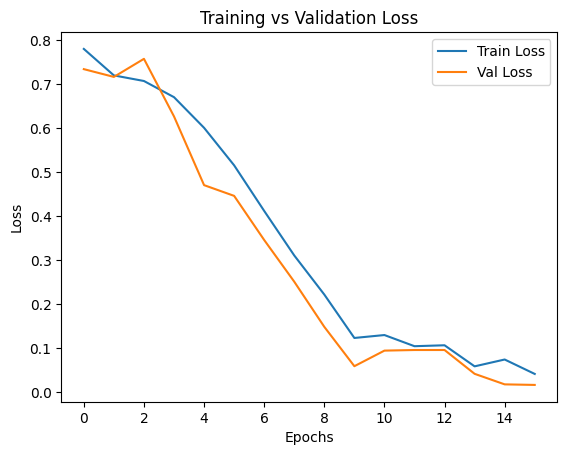

In [ ]:


import os
import torch
import timm
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Paths
train_dir = "Dataset/Dataset/train"
val_dir = "Dataset/Dataset/val"

# Hyperparameters
batch_size = 16
image_size = 224
num_epochs = 16
learning_rate = 1e-4
num_classes = len(os.listdir(train_dir))

# Data transforms
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Datasets
train_dataset = ImageFolder(root=train_dir, transform=transform)
val_dataset = ImageFolder(root=val_dir, transform=transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Load ViT model
model = timm.create_model('vit_base_patch16_224', pretrained=True)
model.head = nn.Linear(model.head.in_features, num_classes)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
train_loss_history, val_loss_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_loss_history.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_images, val_labels = val_images.to(device), val_labels.to(device)
            val_outputs = model(val_images)
            val_loss += criterion(val_outputs, val_labels).item() * val_images.size(0)
            preds = torch.argmax(val_outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(val_labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_loss_history.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Save model
torch.save(model.state_dict(), "vit_model.pth")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Plot training and validation loss
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


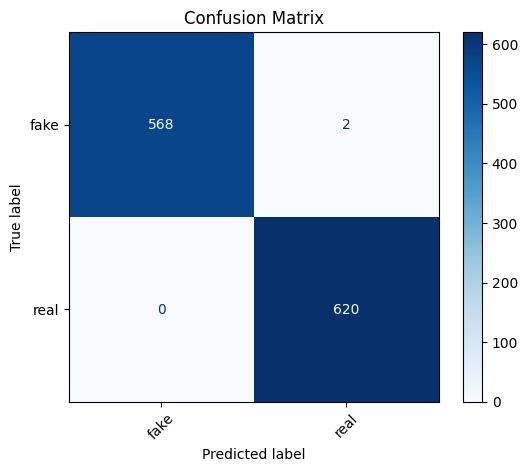

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make sure model is in evaluation mode
model.eval()

# Lists to store true and predicted labels
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = val_dataset.classes  # get class names from dataset

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()
from PIL import Image
import torchvision.transforms as transforms
import torch

# Get uploaded image path
image_path = list(uploaded.keys())[0]
print("📷 Uploaded Image:", image_path)

# Define the same transform used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Prediction function
def predict_image(img_path, model, transform, class_names):
    model.eval()
    img = Image.open(img_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img)
        predicted = torch.argmax(output, 1).item()
    return class_names[predicted]

# Run prediction
predicted_class = predict_image(image_path, model, transform, val_dataset.classes)
print("✅ Predicted Class:", predicted_class)


Saving Gemini_Generated_Image_40n7ey40n7ey40n7.png to Gemini_Generated_Image_40n7ey40n7ey40n7.png
📷 Uploaded Image: Gemini_Generated_Image_40n7ey40n7ey40n7.png
✅ Predicted Class: real


In [ ]:
from google.colab import files

# Download your ViT model file
files.download('/content/vit_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>